In [1]:
Question:
Build a simple scikit-learn predictor to predict one variable from another (e.g., house price from size or test score from study hours).
Follow these steps:

Load data – Create or load a dataset with a feature and a target.

Clean and split – Split into training and test sets.

Choose a model – Use a regression model from scikit-learn (e.g., LinearRegression).

Train the model – Fit it on the training data.

Evaluate – Predict on the test set and calculate performance metrics (MSE, MAE).

Interpret – Briefly discuss the results.

Solution:

We’ll use a simple synthetic dataset: study_hours (feature) → test_score (target).

SyntaxError: invalid character '–' (U+2013) (246852415.py, line 5)

In [2]:
#Step 1: Import libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [3]:
#Step 2: Create synthetic data
# Generate sample data: study hours vs test scores
np.random.seed(42)
study_hours = np.random.uniform(1, 10, 100)  # 100 students, 1 to 10 hours
test_score = 50 + 5 * study_hours + np.random.normal(0, 5, 100)  # linear relation with noise

df = pd.DataFrame({'study_hours': study_hours, 'test_score': test_score})
print(df.head())

   study_hours  test_score
0     4.370861   72.289541
1     9.556429   96.287107
2     7.587945   88.398531
3     6.387926   72.001787
4     2.404168   60.922479


In [4]:
#Step 3: Split into train/test
X = df[['study_hours']]
y = df['test_score']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Train size: (80, 1), Test size: (20, 1)


In [5]:
#Step 4: Train a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# View coefficients
print(f"Intercept: {model.intercept_:.2f}")
print(f"Coefficient: {model.coef_[0]:.2f}")

Intercept: 50.94
Coefficient: 4.78


In [6]:
#Step 5: Predict and evaluate
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")

Mean Squared Error (MSE): 16.34
Mean Absolute Error (MAE): 2.96


In [ ]:
Step 6: Interpretation
The model learned a positive relationship: more study hours generally lead to higher test scores.
The MSE and MAE give an idea of prediction error magnitude. If MSE is much larger than MAE, large errors may exist.
We can also visualize:

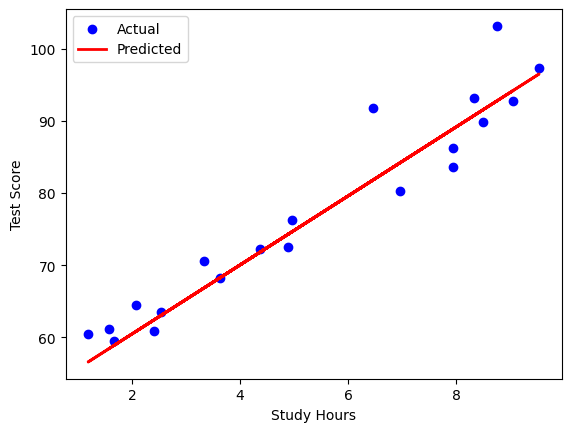

In [7]:
import matplotlib.pyplot as plt
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted')
plt.xlabel('Study Hours')
plt.ylabel('Test Score')
plt.legend()
plt.show()